In [131]:
import pandas as pd
import numpy as np

file_path = "dataset2.csv"
df = pd.read_csv(file_path)

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [132]:
df.shape

(6704, 6)

In [133]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB


In [134]:
df.isna().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [135]:
df.describe(include=object)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14552\3998025828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=object)


,Gender,Education Level,Job Title
count,6702,6701,6702
unique,3,7,193
top,Male,Bachelor's Degree,Software Engineer
freq,3674,2267,518


In [136]:
df.nunique()

Age                     41
Gender                   3
Education Level          7
Job Title              193
Years of Experience     37
Salary                 444
dtype: int64

In [137]:
df.duplicated().sum()

np.int64(4912)

In [138]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

In [139]:
numerical_col = ['Age','Years of Experience','Salary']

corr_matrix = df[numerical_col].corr()
corr_matrix

,Age,Years of Experience,Salary
Age,1.000000,0.937655,0.728053
Years of Experience,0.937655,1.000000,0.808969
Salary,0.728053,0.808969,1.000000


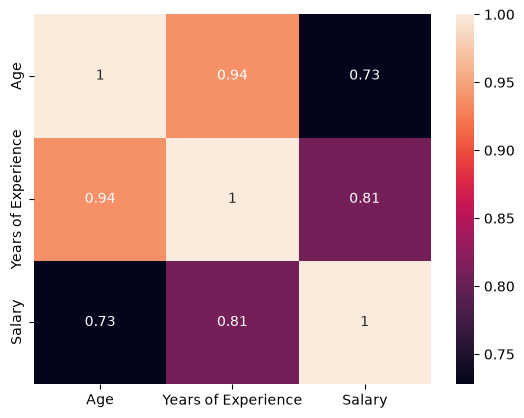

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [141]:
df['Age']=df['Age'].fillna(df['Age'].median)
df.isna().sum()

Age                    0
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [142]:
df = df.replace("<", np.nan)

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
df = df.replace("nan", np.nan)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14552\3866758252.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [143]:

df["Age"], Age_categories = pd.factorize(df["Age"])
df["Age"] = df["Age"].replace(-1, np.nan)  

In [144]:
mean_ex = df.groupby("Age")["Years of Experience"].transform("mean")
mask_ex = df["Years of Experience"].isna()
df.loc[mask_ex, "Years of Experience"] = mean_ex[mask_ex]

In [145]:
mean_s = df.groupby("Years of Experience")["Salary"].transform("mean")
mask_s = df["Salary"].isna()
df.loc[mask_s, "Salary"] = mean_s[mask_s]

In [147]:
df["Education Level"], edu_categories = pd.factorize(df["Education Level"])
df["Education Level"] = df["Education Level"].replace(-1, np.nan)  

df["Gender"], Gender_categories = pd.factorize(df["Gender"])
df["Gender"] = df["Gender"].replace(-1, np.nan)  

df["Job Title"], job_categories = pd.factorize(df["Job Title"])
df["Job Title"] = df["Job Title"].replace(-1, np.nan)  



In [148]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  6704 non-null   int64 
 1   Gender               6704 non-null   int64 
 2   Education Level      6704 non-null   int64 
 3   Job Title            6704 non-null   int64 
 4   Years of Experience  6704 non-null   object
 5   Salary               6704 non-null   object
dtypes: int64(4), object(2)
memory usage: 314.4+ KB


In [149]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

trf1 = ColumnTransformer(
    [
        ('impute_numerical', SimpleImputer(strategy="mean"),
         ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'])
    ],
    remainder="passthrough", verbose_feature_names_out=False
).set_output(transform="pandas")

In [150]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
trf2 = ColumnTransformer([("ohe",OneHotEncoder(sparse_output = False),["Gender","Education Level","Job Title"])],
                         remainder="passthrough",verbose_feature_names_out=False).set_output(transform="pandas")

In [151]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0,0,0,0,5.0,90000.0
1,1,1,1,1,3.0,65000.0
2,2,0,2,2,15.0,150000.0
3,3,1,0,3,7.0,60000.0
4,4,0,1,4,20.0,200000.0


In [152]:
df.isna().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [153]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
trf2=ColumnTransformer([(
    'scaling',
    MinMaxScaler(),
    ['Age','Years of Experience','Salary']
)],
remainder='passthrough',
verbose_feature_names_out=False).set_output(transform='pandas')

In [154]:
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0,0,0,0,5.0,90000.0
1,1,1,1,1,3.0,65000.0
2,2,0,2,2,15.0,150000.0
3,3,1,0,3,7.0,60000.0
4,4,0,1,4,20.0,200000.0
5,5,0,0,5,2.0,55000.0
6,6,1,1,6,12.0,120000.0
7,7,0,0,7,4.0,80000.0
8,8,1,0,8,1.0,45000.0
9,9,0,2,9,10.0,110000.0


<Figure size 500x600 with 0 Axes>

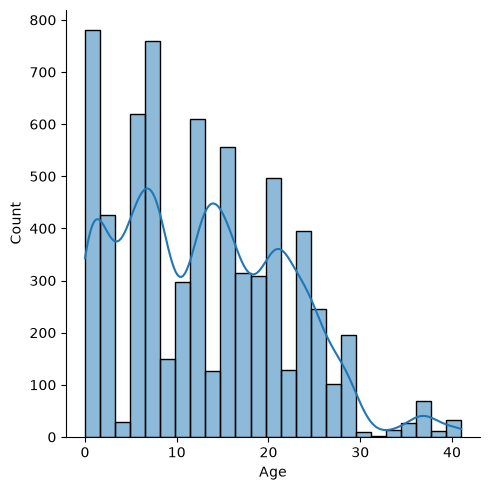

<Figure size 500x600 with 0 Axes>

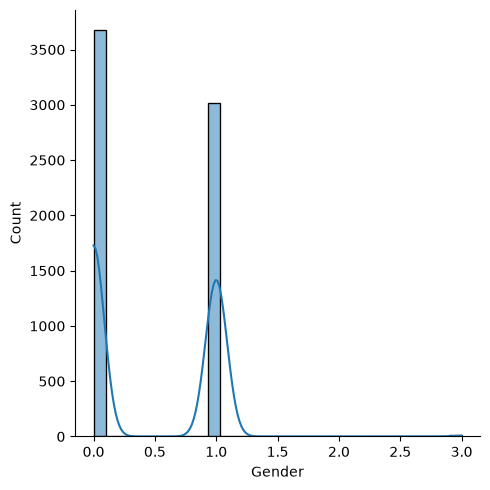

<Figure size 500x600 with 0 Axes>

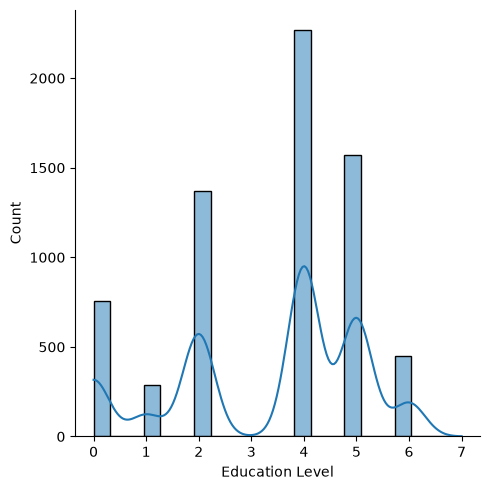

<Figure size 500x600 with 0 Axes>

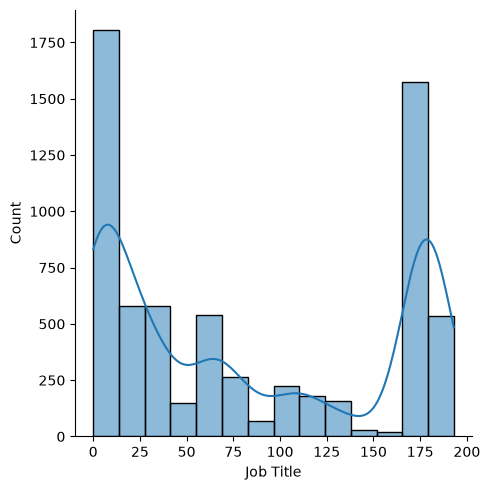

TypeError: Invalid object type at position 172

<Figure size 500x600 with 0 Axes>

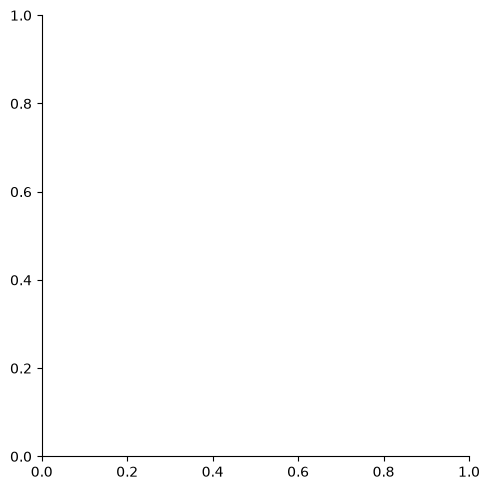

In [155]:
from matplotlib.figure import SubFigure
import matplotlib.pyplot as plt
import seaborn as sns
cols = df.columns.tolist()
for col in cols:
    plt.figure(figsize=(5,6))
    sns.displot(df[col],kde=True)
    plt.show()